# ST1504 Deep Learning Assignment 1
## Part A — CNN Image Classification

Student Name:
Admin Number:
Class:

Objectives:
- Build a CNN image classifier
- Evaluate model performance
- Improve the model using deep learning techniques

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau
from keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

c:\Users\JunHao\anaconda3\envs\gpu_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Dataset Overview

The dataset contains character images for image classification.

Convolutional Neural Networks (CNNs) are suitable because:
- images contain spatial features
- CNNs automatically learn patterns
- convolution layers detect edges, shapes and textures

The dataset contains grayscale image data stored as flattened pixel arrays.

Each row represents:
- 1 label column
- 784 pixel columns corresponding to 28×28 images

In [2]:
#load csv 
df = pd.read_csv("emnist-letters.csv")
print(f" SHAPE OF DF: {df.shape}\n")
print(f"DF INFO: {df.info}\n")

 SHAPE OF DF: (99039, 785)

DF INFO: <bound method DataFrame.info of        24    0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.552  0.553  \
0      -2  142  142  142  142  142  142  142  142  142  ...    142    142   
1      15    0    0    0    0    0    0    0    0    0  ...      0      0   
2      14    0    0    0    0    0    0    0    0    0  ...      0      0   
3      -2  120  120  120  120  120  120  120  120  120  ...    120    120   
4      -1  131  131  131  131  131  131  131  131  200  ...    131    131   
...    ..  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
99034  21    0    0    0    0    0    0    0    0    0  ...      0      0   
99035   8    0    0    0    0    0    0    0    0    0  ...      0      0   
99036  19    0    0    0    0    0    0    0    0    0  ...      0      0   
99037  21    0    0    0    0    0    0    0    0    0  ...      0      0   
99038  23    0    0    0    0    0    0    0    0    0  ...      0      0   

      

In [3]:
print(f"DF HEAD: {df.head()}")

DF HEAD:    24    0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.552  0.553  0.554  \
0  -2  142  142  142  142  142  142  142  142  142  ...    142    142    142   
1  15    0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  14    0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  -2  120  120  120  120  120  120  120  120  120  ...    120    120    120   
4  -1  131  131  131  131  131  131  131  131  200  ...    131    131    131   

   0.555  0.556  0.557  0.558  0.559  0.560  0.561  
0    142    142    142    142    142    142    142  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3    120    120    120    120    120    120    120  
4    131    131    131    131    131    131    131  

[5 rows x 785 columns]


In [4]:
df_clean = df.loc[df.iloc[:,0]>0]
print(df_clean.info())

df_sort = df_clean.sort_values(by='24')
labels = df_sort.iloc[:, 0].values
pixels = df_sort.iloc[:, 1:].values

<class 'pandas.core.frame.DataFrame'>
Index: 88799 entries, 1 to 99038
Columns: 785 entries, 24 to 0.561
dtypes: int64(785)
memory usage: 532.5 MB
None


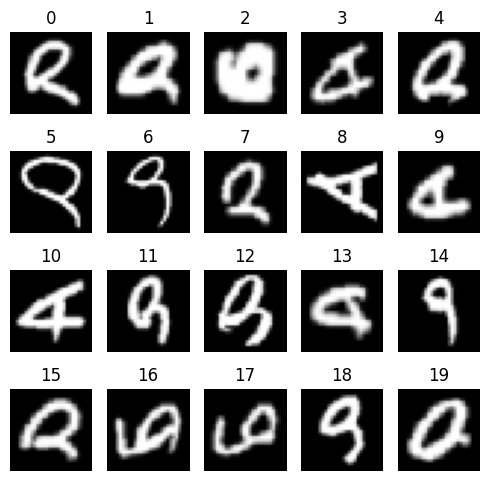

In [5]:
plt.figure(figsize=(5,5))

rows = 4
cols = 5

for i in range(rows * cols):

    img = pixels[i].reshape(28, 28)

    plt.subplot(rows, cols,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(i)
    plt.axis('off')
plt.tight_layout()
plt.show()

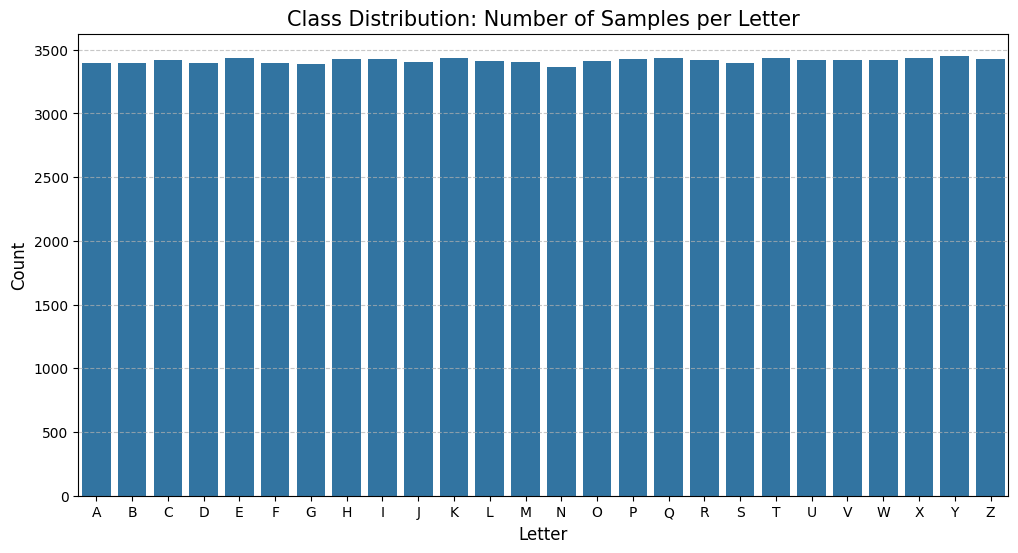

Total samples: 99039
Mean samples per class: 3415.35
Standard Deviation: 20.28


In [6]:
# Get the counts of each label
label_counts = df_clean.iloc[:, 0].value_counts().sort_index()

# Map the numeric labels (1-26) to actual letters (A-Z) for the plot
label_names = [chr(ord('A') + i - 1) for i in label_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=label_names, y=label_counts.values)

# Add labels and title
plt.title("Class Distribution: Number of Samples per Letter", fontsize=15)
plt.xlabel("Letter", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


print(f"Total samples: {len(df)}")
print(f"Mean samples per class: {label_counts.mean():.2f}")
print(f"Standard Deviation: {label_counts.std():.2f}")

## Data Preprocessing

Images are resized to a fixed size for consistency.
Pixel values are normalized to improve training stability.

Data augmentation is applied to:
- reduce overfitting
- improve generalization
- simulate unseen variations

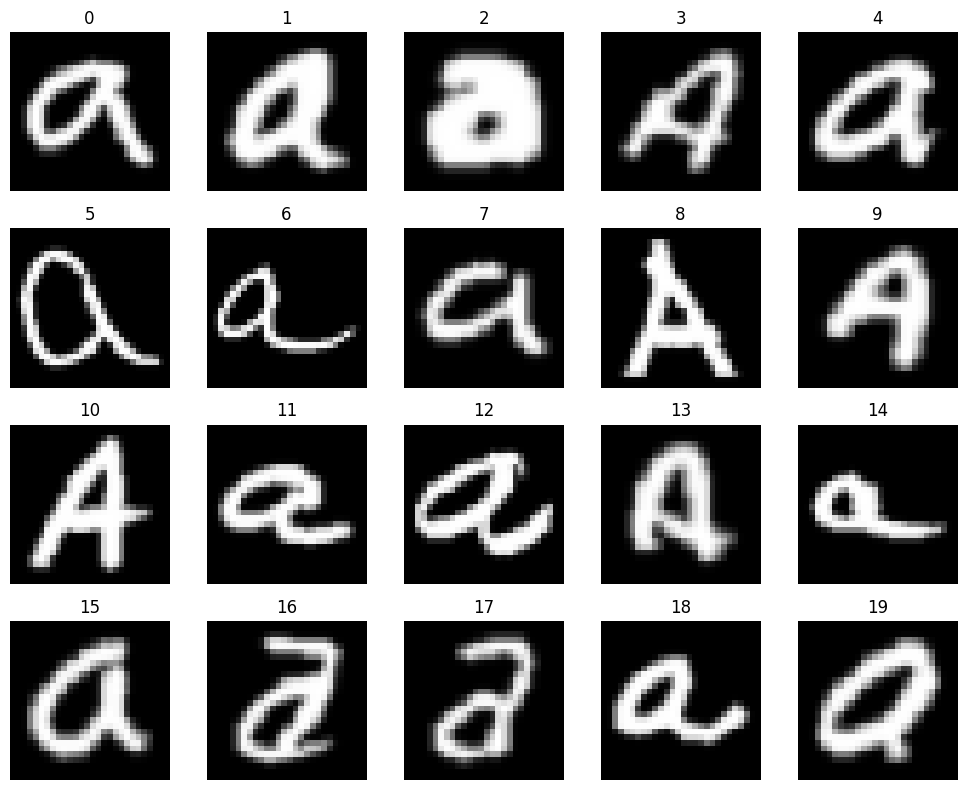

In [7]:
plt.figure(figsize=(10, 8))

rows = 4
cols = 5

for i in range(rows * cols):
    
    # the EMNIST format is column-major and i transformed it to row-major to align with standard image processing libraries
    img = pixels[i].reshape(28, 28).T

    plt.subplot(rows, cols,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(i)
    plt.axis('off')
plt.tight_layout()
plt.show()

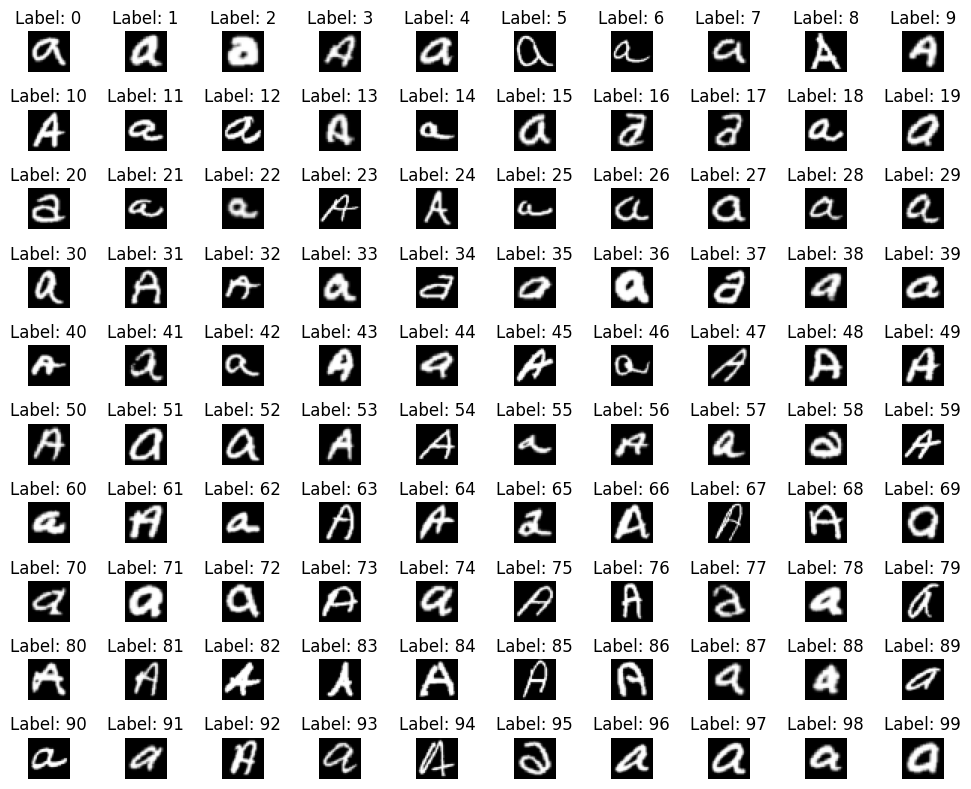

In [8]:
# Reshape to (Number of images, 28, 28)
# Transpose axes 1 and 2 (the width and height)
# Reshape back to (Number of images, 784) if you need it flat for the model
pixels_reshaped = pixels.reshape(-1, 28, 28).transpose(0, 2, 1)
pixels_transposed_flat = pixels_reshaped.reshape(-1, 784)
plt.figure(figsize=(10, 8))

no = 10

# Use the pre-transposed reshaped data
for i in range(no * no):
    plt.subplot(no, no, i + 1)
    plt.imshow(pixels_reshaped[i], cmap='gray') 
    plt.title(f"Label: {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Feature engineering and data augmentation

In [9]:
# Before augmenting, reshape the data into the 4D format that Keras expects: (batch_size, height, width, channels)
# Normalize pixels to [0, 1] for better CNN convergence
X = pixels.astype('float32') / 255.0

X = X.reshape(-1, 28, 28)
X = np.array([img.T for img in X])
X = X.reshape(-1, 28, 28, 1) 

# One-hot encode labels (EMNIST letters are 1-26)
from tensorflow.keras.utils import to_categorical
y = to_categorical(labels - 1, num_classes=26)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelling and evaluation

## Baseline CNN Architecture

The baseline model consists of:
- convolution layers for feature extraction
- max pooling for dimensionality reduction
- dense layers for classification

## Baseline CNN Model

A simple CNN architecture was first developed to establish baseline performance.

This model contains:
- 2 convolutional layers
- max pooling layers
- fully connected dense layers

No regularization or normalization techniques were applied at this stage.

In [10]:
baseline_model = Sequential([

    Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu'),
    MaxPooling2D((2,2)),

    Dropout(0.2),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(y_test.shape[1], activation='softmax')
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    'best_baseline_model.h5',   # file name
    monitor='val_accuracy',     # save based on best validation accuracy
    save_best_only=True,
    mode='max',
    verbose=1
)

baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 12, 12, 32)        0         
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 128)               589952    
                                                                 
 dense_1 (Dense)             (None, 26)                3354      
                                                        

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
1110/1110 [==============================] - ETA: 0s - loss: 1.2721 - accuracy: 0.6426
Epoch 1: val_accuracy improved from -inf to 0.75236, saving model to best_baseline_model.h5
1110/1110 [==============================] - 19s 16ms/step - loss: 1.2721 - accuracy: 0.6426 - val_loss: 0.8305 - val_accuracy: 0.7524
Epoch 2/20
1110/1110 [==============================] - ETA: 0s - loss: 0.7227 - accuracy: 0.7871
Epoch 2: val_accuracy improved from 0.75236 to 0.81126, saving model to best_baseline_model.h5
1110/1110 [==============================] - 23s 20ms/step - loss: 0.7227 - accuracy: 0.7871 - val_loss: 0.6259 - val_accuracy: 0.8113
Epoch 3/20
1110/1110 [==============================] - ETA: 0s - loss: 0.5569 - accuracy: 0.8331
Epoch 3: val_accuracy improved from 0.81126 to 0.84809, saving model to best_baseline_model.h5
1110/1110 [==============================] - 18s 16ms/step - loss: 0.5569 - accuracy: 0.8331 - val_loss: 0.5035 - val_accuracy: 0.8481
Epoch 4/20
1108/111

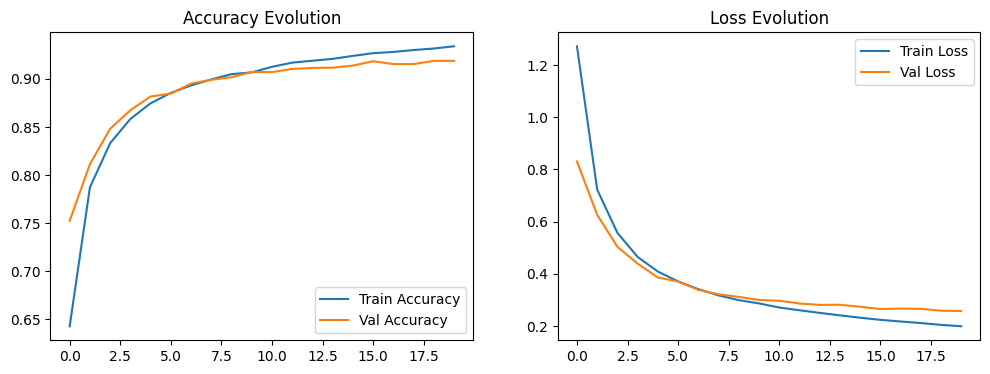

In [12]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['accuracy'], label='Train Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['loss'], label='Train Loss')
plt.plot(baseline_history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

## Baseline Model Analysis

The model achieved good training accuracy but lower validation accuracy,
indicating overfitting.

Certain classes were frequently misclassified due to:
- similar visual appearance
- insufficient training samples
- lack of image diversity

## Improvement 1 - Data augmentation
Data augmentation was introduced to improve generalization and reduce overfitting

## Improvement 2 - Dropout
Dropout reduces overfitting and randomly disables neurons.

## Improvement 3 - Batch Normalisation
Batch normalisation stabalizes training and speeds convergence. 

## Improvement 4 - Deeper CNN

Adds more Conv layers and more filters

## Improvement 6 - Save Best Weights

checkpoint = ModelCheckpoint(
    "best_model.h5",
    save_best_only=True
)

## Improved CNN Architecture

A deeper CNN architecture was implemented to improve feature extraction capability.

Additional techniques were introduced:
- Batch Normalization
- Dropout Regularization
- Data Augmentation
- Early Stopping

These were added to reduce overfitting and improve generalization performance.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
complex_cnn = Sequential([

    # =================================
    # Block 1
    # =================================

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(28,28,1)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.25),

    # =================================
    # Block 2
    # =================================

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),
    Dropout(0.30),

    # =================================
    # Head
    # =================================

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.40),

    Dense(26, activation='softmax')
])

complex_cnn.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

complex_cnn.summary()
checkpoint = ModelCheckpoint( 'complex_cnn.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1 ) 
improved_history = complex_cnn.fit( X_train, y_train, batch_size=64, epochs=30, validation_data=
(X_test, y_test), callbacks=[ early_stop, reduce_lr, checkpoint ])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_1 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 conv2d_5 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 batch_normalization_2 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                      

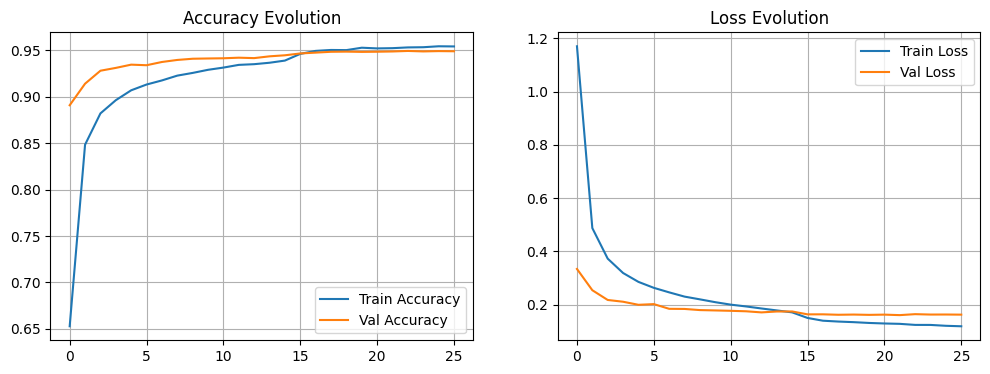

In [14]:
# accuracy graph
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(improved_history.history['accuracy'], label='Train Accuracy')
plt.plot(improved_history.history['val_accuracy'], label='Val Accuracy')

plt.grid(True)
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(improved_history.history['loss'], label='Train Loss')
plt.plot(improved_history.history['val_loss'], label='Val Loss')

plt.grid(True)
plt.title('Loss Evolution')
plt.legend()

plt.show()

# Improved complex cnn

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'improved_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(28,28,1)
))

model.add(BatchNormalization())

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))
model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.40))
model.add(Dense(
    26,
    activation='softmax'
))

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_cnn_history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
1110/1110 [==============================] - ETA: 0s - loss: 1.1469 - accuracy: 0.6573
Epoch 1: val_accuracy improved from -inf to 0.88818, saving model to improved_cnn_model.h5
1110/1110 [==============================] - 127s 114ms/step - loss: 1.1469 - accuracy: 0.6573 - val_loss: 0.3378 - val_accuracy: 0.8882 - lr: 3.0000e-04
Epoch 2/30
1110/1110 [==============================] - ETA: 0s - loss: 0.4866 - accuracy: 0.8468
Epoch 2: val_accuracy improved from 0.88818 to 0.91425, saving model to improved_cnn_model.h5
1110/1110 [==============================] - 154s 139ms/step - loss: 0.4866 - accuracy: 0.8468 - val_loss: 0.2593 - val_accuracy: 0.9142 - lr: 3.0000e-04
Epoch 3/30
1110/1110 [==============================] - ETA: 0s - loss: 0.3729 - accuracy: 0.8810
Epoch 3: val_accuracy improved from 0.91425 to 0.92669, saving model to improved_cnn_model.h5
1110/1110 [==============================] - 142s 128ms/step - loss: 0.3729 - accuracy: 0.8810 - val_loss: 0.2177 - val

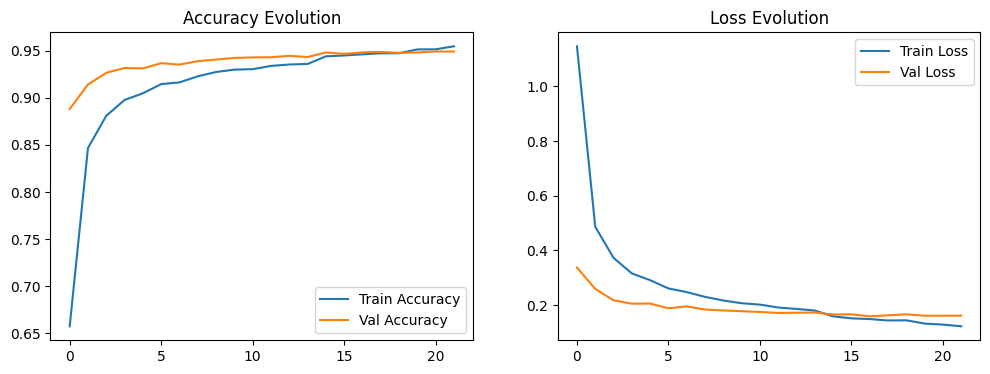

In [16]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(improved_cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(improved_cnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(improved_cnn_history.history['loss'], label='Train Loss')
plt.plot(improved_cnn_history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

## Model Comparison Analysis

The baseline CNN achieved very high training accuracy (98%) but lower validation accuracy (92%), indicating overfitting.

The improved CNN achieved lower training accuracy (93.35%) but higher validation accuracy (94.81%).

This suggests that:
- dropout regularization
- batch normalization
- data augmentation

successfully improved the model's ability to generalize to unseen data.

Although the improved model learned the training data less aggressively, it performed better on validation data, making it the superior model overall.

555/555 [==============================] - 6s 10ms/step


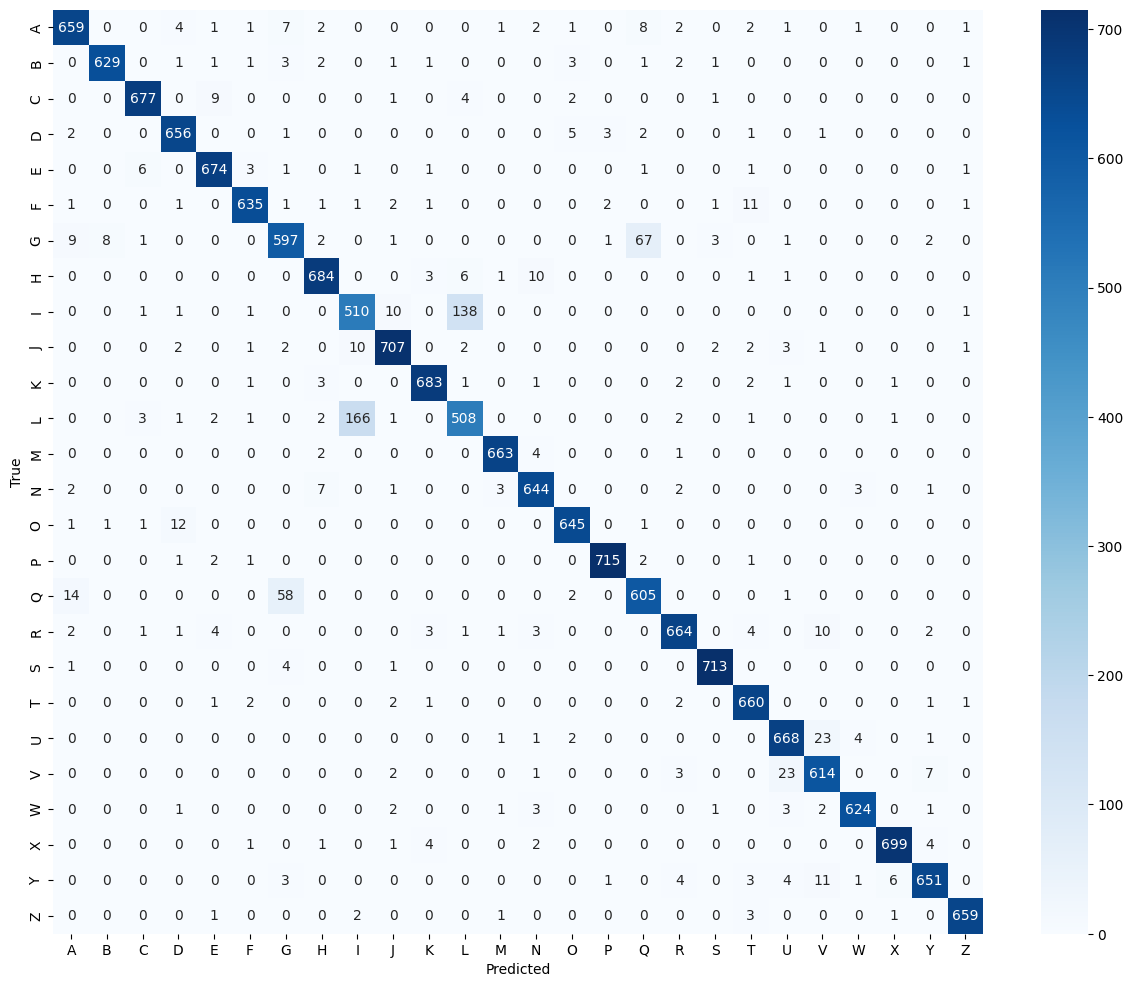

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       693
           1       0.99      0.97      0.98       647
           2       0.98      0.98      0.98       694
           3       0.96      0.98      0.97       671
           4       0.97      0.98      0.97       689
           5       0.98      0.97      0.97       658
           6       0.88      0.86      0.87       692
           7       0.97      0.97      0.97       706
           8       0.74      0.77      0.75       662
           9       0.97      0.96      0.97       733
          10       0.98      0.98      0.98       695
          11       0.77      0.74      0.75       688
          12       0.99      0.99      0.99       670
          13       0.96      0.97      0.97       663
          14       0.98      0.98      0.98       661
          15       0.99      0.99      0.99       722
          16       0.88      0.89      0.89       680
          17       0.97    

In [17]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

conf_mtx = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(conf_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=[chr(ord('A')+i) for i in range(26)],
            yticklabels=[chr(ord('A')+i) for i in range(26)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred_classes))

In [10]:
def get_data_augmentation():
    datagen = ImageDataGenerator(
        rotation_range=10, 
        zoom_range=0.1, 
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=False,
        vertical_flip=False,
        fill_mode='nearest'
    )
    return datagen

# Initialize the generator
datagen = get_data_augmentation()

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'augmented_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(28,28,1)
))

model.add(BatchNormalization())

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))
model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.40))
model.add(Dense(
    26,
    activation='softmax'
))

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
datagen.fit(X_train)

augmented_history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=len(X_train) // 64, 
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/50
1109/1109 [==============================] - ETA: 0s - loss: 1.5062 - accuracy: 0.5535
Epoch 1: val_accuracy improved from -inf to 0.86537, saving model to augmented_cnn_model.h5
1109/1109 [==============================] - 156s 139ms/step - loss: 1.5062 - accuracy: 0.5535 - val_loss: 0.4213 - val_accuracy: 0.8654 - lr: 3.0000e-04
Epoch 2/50
1109/1109 [==============================] - ETA: 0s - loss: 0.6632 - accuracy: 0.7903
Epoch 2: val_accuracy improved from 0.86537 to 0.91768, saving model to augmented_cnn_model.h5
1109/1109 [==============================] - 167s 151ms/step - loss: 0.6632 - accuracy: 0.7903 - val_loss: 0.2421 - val_accuracy: 0.9177 - lr: 3.0000e-04
Epoch 3/50
1109/1109 [==============================] - ETA: 0s - loss: 0.5056 - accuracy: 0.8402
Epoch 3: val_accuracy improved from 0.91768 to 0.92061, saving model to augmented_cnn_model.h5
1109/1109 [==============================] - 149s 134ms/step - loss: 0.5056 - accuracy: 0.8402 - val_loss: 0.2305 - 

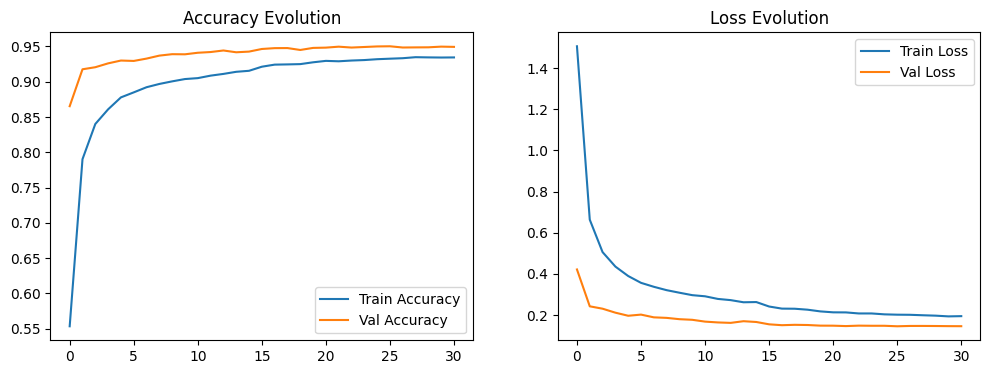

In [14]:
# accuracy graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(augmented_history.history['accuracy'], label='Train Accuracy')
plt.plot(augmented_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(augmented_history.history['loss'], label='Train Loss')
plt.plot(augmented_history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

In [ ]:
# Extract the highest validation accuracy for each model
baseline_acc = max(baseline_history.history['val_accuracy'])
complex_acc = max(improved_history.history['val_accuracy']) # The one without augmentation
aug_acc = max(augmented_history.history['val_accuracy'])          # The one with augmentation

# Store them in a list for plotting
accuracies = [baseline_acc, complex_acc, aug_acc]
model_names = ['Baseline CNN', 'Complex CNN', 'Complex + Augmentation']

NameError: name 'history' is not defined

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

bars = plt.bar(model_names, accuracies, color=['#3498db', '#e67e22', '#2ecc71'])

plt.title('EMNIST Model Performance Comparison', fontsize=16)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.show()